In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# <h1 style="text-align: center;" class="list-group-item list-group-item-action active" data-toggle="list" role="tab" aria-controls="home">FRAUD DETECTION</h1>

![](https://cdn.dnaindia.com/sites/default/files/styles/full/public/2017/04/04/562375-cyberfraud-040417.jpg)

**Image credit:** [dnaindia](https://www.dnaindia.com/mumbai/report-goregaon-man-duped-of-rs-30k-in-credit-card-fraud-2380446)

# WELCOME!

Welcome to "***Fraud Detection ***"study.

In this study without knowing what the column names are, we will only be interested in their values. 

We will implement ***Logistic Regression, Random Forest, Neural Network*** algorithms and ***SMOTE*** technique. Also visualize performances of the models using ***Seaborn, Matplotlib, Plotly*** and ***Yellowbrick*** in a variety of ways.

<a id="toc"></a>

## <h3 style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;" class="list-group-item list-group-item-action active" data-toggle="list" role="tablist" aria-controls="home">TABLE OF CONTENTS</h3>

* [1 - DATA](#1)
    * [1.1 Context](#1.1)
    * [1.2 About the Features](#1.2) 
    * [1.3 What the Problem is](#1.3) 
    * [1.4 Project Structure & Tasks](#1.4) 
* [2 - LIBRARIES NEEDED IN THE STUDY](#2)
    * [2.1 User Defined Functions](#2.1)
* [3 - ANALYSIS](#3)
    * [3.1 Loading & Reading the Data](#3)
* [4 - EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION](#4)
    * [4.1 A General Look at the Data](#4.1)
    * [4.2 Examination of Features and Data Insights](#4.2)
    * [4.3 Data Cleaning](#4.3)
* [5 - MODEL BUILDING WITHOUT SMOTE](#5)
    * [5.1 Data Pre - Processing](#5.1)          
        * [5.1.1 Scalling](#5.1.1)
        * [5.1.2 Train - Test Split](#5.1.2)
    * [5.2 Logistic Regression without SMOTE](#5.2)
        * [5.2.1 Model Building](#5.2.1)
        * [5.2.2 Evaluating Model Performance](#5.2.2)
        * [5.2.3 Logistic Regression Cross Validation](#5.2.3)
        * [5.2.4 Logistic Regression GridSearchCV](#5.2.4)
        * [5.2.5 Logistic Regression ROC (Receiver Operating Curve) & AUC (Area Under Curve)](#5.2.5)            
        * [5.2.6 Prediction](#5.2.6)        
    * [5.3 Random Forest Classifier without SMOTE](#5.3)
        * [5.3.1 Model Building](#5.3.1)
        * [5.3.2 Evaluating Model Performance](#5.3.2)
        * [5.3.3 Feature Importance for Random Forest Model](#5.3.3) 
        * [5.3.4 Random Forest Classifier Cross Validation](#5.3.4)
        * [5.3.5 Random Forest Classifier GridSearchCV](#5.3.5)
        * [5.3.6 Random Forest Classifier ROC (Receiver Operating Curve) and AUC (Area Under Curve)](#5.3.6) 
        * [5.3.7 Prediction](#5.3.7) 
* [6 - MODEL BUILDING WITH SMOTE](#6)
    * [6.1 Data Pre - Processing](#6.1)          
        * [6.1.1 Scalling](#6.1.1)
        * [6.1.2 Train - Test Split](#6.1.2)
    * [6.2 Logistic Regression with SMOTE](#6.2)
        * [6.2.1 Model Building](#6.2.1)
        * [6.2.2 Evaluating Model Performance](#6.2.2)
        * [6.2.3 Logistic Regression Cross Validation](#6.2.3)
        * [6.2.4 Logistic Regression GridSearchCV](#6.2.4)
        * [6.2.5 Logistic Regression ROC (Receiver Operating Curve) & AUC (Area Under Curve)](#6.2.5)            
        * [6.2.6 Prediction](#6.2.6)        
    * [6.3 Random Forest Classifier with SMOTE](#6.3)
        * [6.3.1 Model Building](#6.3.1)
        * [6.3.2 Evaluating Model Performance](#6.3.2)
        * [6.3.3 Random Forest Classifier Cross Validation](#6.3.3)
        * [6.3.4 Random Forest Classifier GridSearchCV](#6.3.4)
        * [6.3.5 Random Forest Classifier ROC (Receiver Operating Curve) and AUC (Area Under Curve)](#6.3.5)     
        * [6.3.6 Prediction](#6.3.6) 
* [7 - NEURAL NETWORK](#7)
    * [7.1 Data Pre - Processing](#7.1)          
        * [7.1.1 Scalling](#7.1.1)
        * [7.1.2 Train - Test Split](#7.1.2)
    * [7.2 Import Libraries](#7.2)
    * [7.3 Define Model](#7.3)
    * [7.4 Compile Model](#7.4)
    * [7.5 Fit Model](#7.5)
    * [7.6 Evaluating Model Performance](#7.6)
    * [7.7 Neural Network GridSearchCV](#7.7)
    * [7.8 Neural Network ROC (Receiver Operating Curve) & AUC (Area Under Curve)](#7.8)  
    * [7.9 Prediction](#7.9)  
* [8 - THE COMPARISON OF MODELS](#8)   
* [9 - FINAL MODEL](#9)
* [10 - MODEL DEPLOYMENT](#10)
    * [10.1 Save and Export the Model as .pkl](#10.1)
    * [10.2 Example of An Application Code for Deployment](#9.2)  
* [11 - CONCLUSION](#11)


<a id="1"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">1 - DATA</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

The datasets contains transactions made by credit cards in September 2013 by european cardholders. This dataset presents transactions that occurred in two days, where it has **492 frauds** out of **284,807** transactions. The dataset is **highly unbalanced**, the positive class (frauds) account for 0.172% of all transactions.

**For a better understanding and more information, please refer to https://www.kaggle.com/mlg-ulb/creditcardfraud**

<a id="1.1"></a>
### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:left; border-radius:10px 10px;">1.1 Context</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

Fraud that involves cell phones, insurance claims, tax return claims, credit card transactions, government procurement etc. represent significant problems for governments and businesses and specialized analysis techniques for discovering fraud using them are required. These methods exist in the areas of Knowledge Discovery in Databases (KDD), Data Mining, Machine Learning and Statistics. They offer applicable and successful solutions in different areas of electronic fraud crimes.

In general, the primary reason to use data analytics techniques is to tackle fraud since many internal control systems have serious weaknesses. For example, the currently prevailing approach employed by many law enforcement agencies to detect companies involved in potential cases of fraud consists in receiving circumstantial evidence or complaints from whistleblowers. As a result, a large number of fraud cases remain undetected and unprosecuted. In order to effectively test, detect, validate, correct error and monitor control systems against fraudulent activities, businesses entities and organizations rely on specialized data analytics techniques such as data mining, data matching, sounds like function, Regression analysis, Clustering analysis and Gap. Techniques used for fraud detection fall into two primary classes: statistical techniques and artificial intelligence.

https://en.wikipedia.org/wiki/Data_analysis_techniques_for_fraud_detection

<a id="1.2"></a>
### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:left; border-radius:10px 10px;">1.2 About The Features</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, it is not provided the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

**Feature Information:**

**Time**: This feature is contains the seconds elapsed between each transaction and the first transaction in the dataset. 

**Amount**:  This feature is the transaction Amount, can be used for example-dependant cost-senstive learning. 

**Class**: This feature is the target variable and it takes value 1 in case of fraud and 0 otherwise.

<a id="1.3"></a>
### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:left; border-radius:10px 10px;">1.3 What the Problem is</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

The aim of this study is to predict whether a credit card transaction is fraudulent. Of course, this is not easy to do.
First of all, we need to analyze and recognize the data well in order to draw a roadmap and choose the correct arguments to use. Accordingly, we can examine the frequency distributions of variables. We can observe variable correlations and want to explore multicollinearity. We can show the distribution of the target variable's classes over other variables. 
Also, it is useful to take missing values and outliers.

After these procedures, we can move on to the model building stage by doing the basic data pre-processing we are familiar with. 

<a id="1.4"></a>
### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:left; border-radius:10px 10px;">1.4 Project Structure & Tasks</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#e9a1ed" data-toggle="popover">Table of Contents</a>

#### 1. Exploratory Data Analysis & Data Cleaning

- Import Modules, Load Data & Data Review
- Exploratory Data Analysis
- Data Cleaning
    
#### 2. Data Preprocessing

- Scaling
- Train - Test Split

#### 3. Model Building

- Logistic Regression without SMOTE
- Apply SMOTE
- Logistic Regression with SMOTE
- Random Forest Classifier with SMOTE
- Neural Network

#### 4. Model Deployement

- Save and Export the Model as .pkl
- Save and Export Variables as .pkl 

<a id="2"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">2 - LIBRARIES NEEDED IN THE STUDY<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
## Import Libraies

## import all main libraries automatically with pyforest
# !pip install pyforest
# !pip install pycaret[full]

# import pyforest

## main libraries
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker

# !pip install squarify
import squarify as sq

import scipy.stats as stats
from scipy.cluster.hierarchy import linkage, dendrogram
import statsmodels.api as sm
import statsmodels.formula.api as smf
import datetime as dt
from datetime import datetime
# from pyclustertend import hopkins

## pre-processing
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer, KNNImputer

## feature Selection
from sklearn.feature_selection import SelectKBest, SelectPercentile, f_classif, f_regression, mutual_info_regression

## scaling
from sklearn.preprocessing import scale 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler

## regression/prediction
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

## ann
from sklearn.neural_network import MLPRegressor

## classification
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier, plot_importance

## metrics
from sklearn.metrics import plot_confusion_matrix, r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import make_scorer, precision_score, precision_recall_curve, plot_precision_recall_curve 
from sklearn.metrics import plot_roc_curve, roc_auc_score, roc_curve, f1_score, accuracy_score, recall_score
from sklearn.metrics import silhouette_samples,silhouette_score, average_precision_score
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics import auc

## model selection
from sklearn import model_selection
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold, KFold, cross_val_predict, train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, cross_validate

## MLearning
from sklearn.pipeline import make_pipeline, Pipeline
import optuna
from sklearn.naive_bayes import GaussianNB

## clevers
# !pip install -U pandas-profiling --user
import pandas_profiling
from pandas_profiling.report.presentation.flavours.html.templates import create_html_assets

import ipywidgets
from ipywidgets import interact
import missingno as msno 
# !pip install wordcloud
from wordcloud import WordCloud

# !pip install termcolor
import colorama
from colorama import Fore, Style  # makes strings colored
from termcolor import colored
from termcolor import cprint
# grey red green yellow blue magenta cyan white (on_grey ..)
# bold dark underline blink reverse concealed
# cprint("Have a first look to:","blue","on_grey", attrs=['bold'])

## plotly and cufflinks
import plotly 
import plotly.express as px
import cufflinks as cf
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

## Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

## Figure&Display options
plt.rcParams["figure.figsize"] = (10,6)
pd.set_option('max_colwidth',200)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<a id="2.1"></a>
### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">2.1 User Defined Functions<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>
    
**We have defined some useful user defined functions.**

In [ ]:
## Some Useful User-Defined-Functions

###############################################################################

def missing_values(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return missing_values[missing_values['Missing_Number']>0]

###############################################################################

def first_looking(df):
    print(colored("Shape:", 'yellow', attrs=['bold']), df.shape,'\n', 
          colored('*'*100, 'red', attrs=['bold']),
          colored("\nInfo:\n",'yellow', attrs=['bold']), sep='')
    print(df.info(), '\n', 
          colored('*'*100, 'red', attrs=['bold']), sep='')
    print(colored("Number of Uniques:\n", 'yellow', attrs=['bold']), df.nunique(),'\n',
          colored('*'*100, 'red', attrs=['bold']), sep='')
    print(colored("Missing Values:\n", 'yellow', attrs=['bold']), missing_values(df),'\n', 
          colored('*'*100, 'red', attrs=['bold']), sep='')
    print(colored("All Columns:", 'yellow', attrs=['bold']), *list(df.columns), sep='\n- ') 
    print(colored('*'*100, 'red', attrs=['bold']), sep='')

    df.columns= df.columns.str.lower().str.replace('&', '_').str.replace(' ', '_')
    
    print(colored("Columns after rename:", 'yellow', attrs=['bold']), *list(df.columns), sep='\n- ')
    print(colored('*'*100, 'red', attrs=['bold']), sep='')
    
###############################################################################
## To view summary information about the columns

def summary(column):
    print(colored("Column: ",'yellow', attrs=['bold']), column)
    print(colored('*'*100, 'red', attrs=['bold']), sep='')
    print(colored("Missing values: ", 'yellow', attrs=['bold']), df[column].isnull().sum())
    print(colored('*'*100, 'red', attrs=['bold']), sep='')
    print(colored("Missing values(%): ", 'yellow', attrs=['bold']), round(df[column].isnull().sum()/df.shape[0]*100, 2))
    print(colored('*'*100, 'red', attrs=['bold']), sep='')
    print(colored("Unique values: ", 'yellow', attrs=['bold']), df[column].nunique())
    print(colored('*'*100, 'red', attrs=['bold']), sep='')
    print(colored("Value counts: \n", 'yellow', attrs=['bold']), df[column].value_counts(dropna = False), sep='')
    print(colored('*'*100, 'red', attrs=['bold']), sep='')
    
###############################################################################
                    
def multicolinearity_control(df):                    
    df_temp = df.corr()
    count = 'Done'
    feature =[]
    collinear= []
    for col in df_temp.columns:
        for i in df_temp.index:
            if abs(df_temp[col][i] > .8 and df_temp[col][i] < 1):
                    feature.append(col)
                    collinear.append(i)
                    cprint(f"multicolinearity alert in between {col} - {i}", "red", attrs=["bold"])
    else:
        cprint(f"There is NO multicollinearity between the features.", "blue", attrs=["bold"])                     
                    
###############################################################################

def duplicate_values(df):
    print(colored("Duplicate check...", 'yellow', attrs=['bold']), sep='')
    duplicate_values = df.duplicated(subset=None, keep='first').sum()
    if duplicate_values > 0:
        df.drop_duplicates(keep='first', inplace=True)
        print(duplicate_values, colored(" Duplicates were dropped!"),'\n',
              colored('*'*100, 'red', attrs=['bold']), sep='')
    else:
        print(colored("There are no duplicates"),'\n',
              colored('*'*100, 'red', attrs=['bold']), sep='')     

###############################################################################
        
def drop_columns(df, drop_columns):
    if drop_columns !=[]:
        df.drop(drop_columns, axis=1, inplace=True)
        print(drop_columns, 'were dropped')
    else:
        print(colored('Missing value control...', 'yellow', attrs=['bold']),'\n',
              colored('If there is a missing value above the limit you have given, the relevant columns are dropped and an information is given.'), sep='')

###############################################################################

def drop_null(df, limit):
    for i in df.isnull().sum().index:
        if (df.isnull().sum()[i]/df.shape[0]*100)>limit:
            print(df.isnull().sum()[i], 'percent of', i ,'were null and dropped')
            df.drop(i, axis=1, inplace=True)
    print(colored('Last shape after missing value control:', 'yellow', attrs=['bold']), df.shape, '\n', 
          colored('*'*100, 'red', attrs=['bold']), sep='')

###############################################################################

def shape_control():
    print('df.shape:', df.shape)
    print('X.shape:', X.shape)
    print('y.shape:', y.shape)
    print('X_train.shape:', X_train.shape)
    print('y_train.shape:', y_train.shape)
    print('X_test.shape:', X_test.shape)
    print('y_test.shape:', y_test.shape)

###############################################################################  

## show values in bar graphic
def show_values_on_bars(axs):
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() + p.get_width() / 2
            _y = p.get_y() + p.get_height()
            value = '{:.2f}'.format(p.get_height())
            ax.text(_x, _y, value, ha="center") 
    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
        
############################################################################### 

'''This function detects the best z-score for outlier detection in the specified column.'''

def outlier_zscore(df, col, min_z=1, max_z = 5, step = 0.05, print_list = False):
    z_scores = stats.zscore(df[col].dropna())
    threshold_list = []
    
    for threshold in np.arange(min_z, max_z, step):
        threshold_list.append((threshold, len(np.where(z_scores > threshold)[0])))
    
    df_outlier = pd.DataFrame(threshold_list, columns = ['threshold', 'outlier_count'])
    df_outlier['pct'] = (df_outlier.outlier_count - df_outlier.outlier_count.shift(-1))/df_outlier.outlier_count*100
    df_outlier['pct'] = df_outlier['pct'].apply(lambda x : x-100 if x == 100 else x)
    best_treshold = round(df_outlier.iloc[df_outlier.pct.argmax(), 0],2)
    IQR_coef = round((best_treshold - 0.675) / 1.35, 2)
    outlier_limit = int(df[col].dropna().mean() + (df[col].dropna().std()) * df_outlier.iloc[df_outlier.pct.argmax(), 0])
    num_outlier = df_outlier.iloc[df_outlier.pct.argmax(), 1]
    percentile_threshold = stats.percentileofscore(df[col].dropna(), outlier_limit)
    plt.plot(df_outlier.threshold, df_outlier.outlier_count)
    plt.vlines(best_treshold, 0, df_outlier.outlier_count.max(), colors="r", ls = ":")
    plt.annotate("Zscore : {}\nIQR_coef : {}\nValue : {}\nNum_outlier : {}\nPercentile : {}".format(best_treshold,
                                                                          IQR_coef,
                                                                          outlier_limit,
                                                                          num_outlier,     
                                                                          (np.round(percentile_threshold, 3), 
                                                                           np.round(100-percentile_threshold, 3))),
                                                                          (best_treshold, df_outlier.outlier_count.max()/2))
    plt.show()
    if print_list:
        print(df_outlier)
    return (plt, df_outlier, best_treshold, IQR_coef, outlier_limit, num_outlier, percentile_threshold)

############################################################################### 

'''This function plots histogram, boxplot and z-score/outlier graphs for the specified column.'''

def outlier_inspect(df, col, min_z = 1, max_z = 5, step = 0.05, max_hist = None, bins = 50):
    fig = plt.figure(figsize=(20, 6))
    fig.suptitle(col, fontsize=16)
    plt.subplot(1,3,1)
    if max_hist == None:
        sns.distplot(df[col], kde=False, bins = 50)
    else :
        sns.distplot(df[df[col]<=max_hist][col], kde=False, bins = 50)
    plt.subplot(1,3,2)
    sns.boxplot(df[col])
    plt.subplot(1,3,3)
    z_score_inspect = outlier_zscore(df, col, min_z = min_z, max_z = max_z, step = step)
    plt.show()
    
############################################################################### 

"""This function gives max/min threshold, number of data, number of outlier and plots its boxplot,
according to the tree type and the entered z-score value for the relevant column."""

def num_outliers(df, col, whis = 1.5):
    q1 = df.groupby("class")[col].quantile(0.25)
    q3 = df.groupby("class")[col].quantile(0.75)
    iqr = q3 - q1
    print("Column_name :", col)
    print("whis :", whis)
    print("-------------------------------------------")
    for i in np.sort(df['class'].unique()):
        min_threshold = q1.loc[i] - whis*iqr.loc[i]
        max_threshold = q3.loc[i] + whis*iqr.loc[i]
        print("min_threshold:", min_threshold, "\nmax_threshold:", max_threshold)
        num_outliers = len(df[df["class"]==i][col][(df[col]<min_threshold) | (df[col]>max_threshold)])
        print(f"Num_of_values for {i} :", len(df[df["class"]==i]))
        print(f"Num_of_outliers for {i} :", num_outliers)
        print("-------------------------------------------")
    return sns.boxplot(y = df[col], x = df["class"], whis=whis)

############################################################################### 

"""This function assigns the NaN-value first and then drop related rows, according to the tree type and the entered
whis value and plots the boxplot for the relevant column. """

def remove_outliers(df, col, whis=1.5):
    q1 = df.groupby("class")[col].quantile(0.25)
    q3 = df.groupby("class")[col].quantile(0.75)
    iqr = q3 - q1
    for i in np.sort(df['class'].unique()):
        min_threshold = q1.loc[i] - whis*iqr.loc[i]
        max_threshold = q3.loc[i] + whis*iqr.loc[i]
        df.loc[((df["class"]==i) & ((df[col]<min_threshold) | (df[col]>max_threshold))), col] = np.nan
    return sns.boxplot(y = df[col], x = df["class"], whis=whis)

############################################################################### 

<a id="3"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">3 - ANALYSIS<p>

<a id="3.1"></a>
### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">3.1 Loading & Reading the Data<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

**How to read and assign the dataset as df: You can [Visit Here](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) (You can define it as what you want instead of df)**

Let's first load the required creditcard dataset using pandas's "read_csv" function.

In [ ]:
# df0 = pd.read_csv('creditcard.csv')
df0=pd.read_csv('../input/creditcardfraud/creditcard.csv')
df = df0.copy()
df.head(3) 

In [ ]:
df.tail(3)

In [ ]:
df.sample(3)

<a id="4"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">4 - DATA CLEANING & EXPLORATORY DATA ANALYSIS (EDA)<p>

**Exploratory Data Analysis is an initial process of analysis, in which we can summarize characteristics of data such as pattern, trends, outliers, and hypothesis testing using descriptive statistics and visualization.**

<a id="4.1"></a>
### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.1 A General Look at the Data<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
first_looking(df)
duplicate_values(df)
drop_columns(df, [])
drop_null(df, 90)
# df.describe().T

In [ ]:
df.describe().T

***According to the basic examinations on the dataset;***

- We have a classification problem.
- We are going to make classification on the target variable "class".
- And we will build a model to get the best classification on the "class" column.
- Because of that we are going to look at the balance of "class" column.
- The dataset has 31 columns and 283726 observations after dropping of duplicated observations.
- All columns contain numerical values. 
- There seems to be no missing value. 

<a id="4.2"></a>
### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.2 Examination of Features and Data Insights<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>
    
**In the given dataset, feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise. So, we can divide data into two groups and compare their characteristics. Here, we can find the average of both the groups using groupby() and mean() function.**   

'class' Column-Target Column

In [ ]:
cprint('Have a first look to "class" column',"green","on_red", attrs=["bold"])
print("-----"*10)
summary('class')

In [ ]:
cprint('Mean values according to the "class" column','green', 'on_red')
df.groupby('class').mean()

In [ ]:
cprint('Descriptive statistics according to the "class==0, Non-Fraudulent"',"green","on_red", attrs=["bold"])
df[df['class'] == 1].describe().T.style.background_gradient(subset = ['mean','min','50%', 'max'], cmap = 'RdPu')

In [ ]:
cprint('Descriptive statistics according to the "class==1, Fraudulent"',"green","on_red", attrs=["bold"])
df[df['class'] == 0].describe().T.style.background_gradient(subset = ['mean','min','50%', 'max'], cmap = 'RdPu')

In [ ]:
fig = px.pie(df, values = df['class'].value_counts(), 
             names = (df['class'].value_counts()).index, 
             title = '"class" Column Distribution')
fig.show()

In [ ]:
y = df['class']
print(f'Percentage of class-1: % {round(y.value_counts(normalize=True)[1]*100,2)} --> \
({y.value_counts()[1]} observations for class-1)\nPercentage of class-0: % {round(y.value_counts(normalize=True)[0]*100,2)} --> ({y.value_counts()[0]} observations for class-0)')

- 'class' column has binary type values.
- We have an imbalanced data. Class frequencies of the target variable are quite imbalanced.
- Almost 0.17 % of the transactions are fraudulent(473).
- Almost 99.83 % of the transactions are non-fraudulent(283253).

**'time' Column**

- Time: This feature is contains the seconds elapsed between each transaction and the first transaction in the dataset.

In [ ]:
cprint("Have a First Look to 'time' Column","green","on_red", attrs=["bold"])
print("-----"*10)
summary('time')

In [ ]:
cprint("Describe Values of Column 'time'","green","on_red", attrs=["bold"])
df.time.describe()

In [ ]:
fig = px.box(df, x = df['time'], color = df['class'], title = 'Boxplot Of Column "time"')
fig.show()

**'amount' Column**

- Amount: This feature is the transaction Amount, can be used for example-dependant cost-senstive learning.

In [ ]:
cprint("Have a First Look to 'amount' Column","green","on_red", attrs=["bold"])
print("-----"*10)
summary('time')

In [ ]:
cprint("Describe Values of Column 'amount'","green","on_red", attrs=["bold"])
df.amount.describe()

In [ ]:
fig = px.box(df, x = df['amount'], color = df['class'], title = 'Boxplot Of Column "amount"')
fig.show()

**All 'v' Columns**

 Features from V1 to V28 are the principal components obtained with PCA.

**The dataset is too large. Let's take a look at how the distribution of class=1 and class=0 by quartiles is shaped.**

In [ ]:
def transaction_transformer(price):
    if price <= 5.600:
        return 'Q-1'
    if 5.600 < price <= 22.700:
        return 'Q-2'
    if 22.700 < price <= 75.510:
        return 'Q-3'
    else:
        return 'Q-4'

In [ ]:
df['transaction_class'] = df['amount'].apply(transaction_transformer)

In [ ]:
fig = px.pie(df, values = df[df['class']==0]['transaction_class'].value_counts(), 
             names = df[df['class']==0]['transaction_class'].value_counts().index, 
             title = 'transaction_class & class==0 Distribution')
fig.show()

In [ ]:
fig = px.pie(df, values = df[df['class']==1]['transaction_class'].value_counts(), 
             names = df[df['class']==1]['transaction_class'].value_counts().index, 
             title = 'transaction_class & class==1 Distribution')
fig.show()

In [ ]:
print('Number of fraudulent transactions for Q-1      : ', df[(df['class']==1) & (df['transaction_class']=='Q-1')]['class'].sum())
print('Total amount of fraudulent transactions for Q-1: ', df[(df['class']==1) & (df['transaction_class']=='Q-1')]['amount'].sum())
print('Mean amount of fraudulent transactions for Q-1 : ', df[(df['class']==1) & (df['transaction_class']=='Q-1')]['amount'].mean())

In [ ]:
print('Number of fraudulent transactions for Q-2      : ', df[(df['class']==1) & (df['transaction_class']=='Q-2')]['class'].sum())
print('Total amount of fraudulent transactions for Q-2: ', df[(df['class']==1) & (df['transaction_class']=='Q-2')]['amount'].sum())
print('Mean amount of fraudulent transactions for Q-2 : ', df[(df['class']==1) & (df['transaction_class']=='Q-2')]['amount'].mean())

In [ ]:
print('Number of fraudulent transactions for Q-3      : ', df[(df['class']==1) & (df['transaction_class']=='Q-3')]['class'].sum())
print('Total amount of fraudulent transactions for Q-3: ', df[(df['class']==1) & (df['transaction_class']=='Q-3')]['amount'].sum())
print('Mean amount of fraudulent transactions for Q-3 : ', df[(df['class']==1) & (df['transaction_class']=='Q-3')]['amount'].mean())

In [ ]:
print('Number of fraudulent transactions for Q-4      : ', df[(df['class']==1) & (df['transaction_class']=='Q-4')]['class'].sum())
print('Total amount of fraudulent transactions for Q-4: ', df[(df['class']==1) & (df['transaction_class']=='Q-4')]['amount'].sum())
print('Mean amount of fraudulent transactions for Q-4 : ', df[(df['class']==1) & (df['transaction_class']=='Q-4')]['amount'].mean())

In [ ]:
df.drop(['transaction_class'], axis = 1, inplace = True)

- As seen above, there are fraudulent transactions in every quarter. 
- Q-1 has the highest number of transactions with 213 transactions.
- Q-4 has the highest amount with 56014.34 amount.

Let's look the correlation and multicollinearity among the features.

In [ ]:
cprint("Heatmap of df",'green', 'on_red', attrs=["bold"])
print("-----"*10)
plt.figure(figsize = (17, 17))
sns.heatmap (df.corr(), annot = True, fmt = '.2f', vmin = -1, vmax = 1)
plt.xticks(rotation = 45);

In [ ]:
multicolinearity_control(df)

In [ ]:
df.corr()['class'].sort_values().drop('class').iplot(kind = 'barh', title = 'Correlation Between the Columns');

***Based on the examinations made above,***

- There is no multicollinearity problem among the features.
- We have weak level correlation between the features and the target column.
- Also there is weak level correlation between the columns.

<a id="4.3"></a>
### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">4.3 Data Cleaning<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

Check Missing Values and Outliers

In [ ]:
cprint("Missing Values","green","on_red", attrs=["bold"])
missing_values(df)

- There seems to be no missing value.

What about the outliers?

In [ ]:
cprint("Boxplots","green","on_red", attrs=["bold"])
%matplotlib inline
index = 0
plt.figure(figsize=(20,20))
for feature in df.columns[2:29]:
    index += 1
    plt.subplot(7,4,index)
    sns.boxplot(x=feature, data=df, whis=1.5)

In [ ]:
cprint("Boxplots","green","on_red", attrs=["bold"])
index = 0
plt.figure(figsize=(20,20))
for feature in df.columns[:30]:
    index += 1
    plt.subplot(8,4,index)
    sns.boxplot(y = feature, x = "class", data = df, whis=3)

In [ ]:
from scipy.stats import zscore
from scipy import stats
from numpy import percentile

- 'outlier_zscore' function detects the best z-score for outlier detection in the specified column.
- 'outlier_inspect' function plots histogram, boxplot and z-score/outlier graphs for the specified column.

In [ ]:
cprint("Outlier Inspection","green","on_red", attrs=["bold"])
for col in df.columns[:30]:
    outlier_inspect(df, col)

**Evaluation**

1. There is no missing value in this data set.
2. When each feature is examined, although it is seen that there are outliers in the boxplots, it is evaluated that this dataset does not actually have an outlier.
3. However, since it was considered that the data with a z-score value above 4.73 (IQR_coef = 3) according to the class type would adversely affect the model, so I decided to assign the Nan-Value to these data first and then drop them.

In [ ]:
IQR_coef = 3
z_score = round(0.675 + IQR_coef*1.35, 2)
z_score

In [ ]:
z_score = 3
iqr_coef = round((z_score - 0.675) / 1.35, 2)
iqr_coef

Let's create a new df before outlier operation.

In [ ]:
df_out = df.copy()

In [ ]:
cprint("Shape of new df before outlier check",'green', 'on_red', attrs=["bold"])
df_out.shape

In [ ]:
cprint("Value counts of 'class' column before outlier check",'green', 'on_red', attrs=["bold"])
df_out['class'].value_counts(dropna=False)

In [ ]:
cprint("Missing value control before outlier check",'green', 'on_red', attrs=["bold"])
missing_values(df_out)

- 'num_outliers' function gives max/min threshold, number of data, number of outlier and plots its boxplot,
according to the tree type and the entered z-score value for the relevant column.
- We can see the number of outliers column by column below.

In [ ]:
for col in df_out.columns[:30]:
    num_outliers(df_out, col, whis=3)

- 'remove_outliers' function assigns the NaN-value first and then drop related rows, according to the class and the entered
whis value and plots the boxplot for the relevant column.

In [ ]:
for col in df_out.columns[1:30]:
    remove_outliers(df_out, col, whis=3)

In [ ]:
cprint("Missing value control after outlier check",'green', 'on_red', attrs=["bold"])
missing_values(df_out)

In [ ]:
df_out.dropna(inplace=True)

In [ ]:
cprint("Missing value control after outlier check",'green', 'on_red', attrs=["bold"])
missing_values(df_out)

In [ ]:
cprint("Shape of new df after outlier check",'green', 'on_red', attrs=["bold"])
df_out.shape

In [ ]:
cprint("Value counts of 'class' column after outlier check",'green', 'on_red', attrs=["bold"])
df_out['class'].value_counts(dropna=False)

---
---


<a id="5"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">5 - MODEL BUILDING WITHOUT SMOTE<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

---------
This dataset is severely unbalanced (most of the transactions are non-fraud). 
    
We will make class prediction with three different algorithms. 
    
It is important that we can evaluate the effectiveness of SMOTE. For this reason, implement the Logistic Regression and Random Forest Classifier algorithms in two different ways, with SMOTE applied and without.

In [ ]:
def eval(model, X_train, X_test):
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    
    print(confusion_matrix(y_test, y_pred))
    print("Test_Set")
    print(classification_report(y_test,y_pred))
    print("Train_Set")
    print(classification_report(y_train,y_pred_train))
    print("---"*20)
    plot_confusion_matrix(model, X_test, y_test, cmap="plasma")

In [ ]:
def train_val(y_train, y_train_pred, y_test, y_pred):
    
    scores = {"train_set": {"Accuracy" : accuracy_score(y_train, y_train_pred),
                            "Precision" : precision_score(y_train, y_train_pred),
                            "Recall" : recall_score(y_train, y_train_pred),                          
                            "f1" : f1_score(y_train, y_train_pred),
                            "roc_auc" : roc_auc_score(y_train, y_train_pred),
                            "recall_auc" : auc(recall, precision)},
    
              "test_set": {"Accuracy" : accuracy_score(y_test, y_pred),
                           "Precision" : precision_score(y_test, y_pred),
                           "Recall" : recall_score(y_test, y_pred),                          
                           "f1" : f1_score(y_test, y_pred),
                           "roc_auc" : roc_auc_score(y_test, y_pred),
                           "recall_auc" : auc(recall, precision)}}
    
    return pd.DataFrame(scores)

<a id="5.1"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">5.1 Data Pre - Processing<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

<a id="5.1.1"></a>
#### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.1.1 Scaling<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
df_ml = df_out.copy()

In [ ]:
scaler = StandardScaler()

df_ml["amount"] = scaler.fit_transform(df_ml["amount"].values.reshape(-1,1))
df_ml["time"] = scaler.fit_transform(df_ml["time"].values.reshape(-1,1))

<a id="5.1.2"></a>
#### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.1.2 Train - Test Split<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
X = df_ml.drop(['class'], axis = 1)
y = df_ml['class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 42)

In [ ]:
print('X_train.shape : ', X_train.shape)
print('X_test.shape  : ', X_test.shape)

In [ ]:
cprint('y_train.value_counts','green', 'on_red')
y_train.value_counts()

In [ ]:
cprint('y_test.value_counts','green', 'on_red')
y_test.value_counts()

<a id="5.2"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">5.2 Logistic Regression without SMOTE<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

<a id="5.2.1"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.2.1 Model Building with Logistic Regression</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
LogReg_model = LogisticRegression(solver='liblinear', class_weight = 'balanced', random_state = 42)
LogReg_model.fit(X_train, y_train)
y_pred = LogReg_model.predict(X_test)
y_train_pred = LogReg_model.predict(X_train)

<a id="5.2.2"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.2.2 Evaluating Model Performance</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
LogReg_model_f1 = f1_score(y_test, y_pred)
LogReg_model_acc = accuracy_score(y_test, y_pred)
LogReg_model_recall = recall_score(y_test, y_pred)
LogReg_model_auc = roc_auc_score(y_test, y_pred)
LogReg_model_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
LogReg_model_recall_auc = auc(recall, precision)

In [ ]:
print("LogReg_Model")
print ("------------------")
eval(LogReg_model, X_train, X_test)

In [ ]:
cprint('LogReg_model Scores','green', 'on_red')
train_val(y_train, y_train_pred, y_test, y_pred)

In [ ]:
from yellowbrick.classifier import ClassPredictionError
visualizer = ClassPredictionError(LogReg_model)
# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)
# Evaluate the model on the test data
visualizer.score(X_test, y_test)
# Draw visualization
visualizer.poof();

<a id="5.2.3"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.2.3 Logistic Regression Cross Validation</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('Cross Validation scores for Logistic Regression with default parameters','green', 'on_red')

LogReg_cv = LogisticRegression(solver='liblinear', class_weight = 'balanced', random_state = 42)
LogReg_cv_scores = cross_validate(LogReg_cv, X_train, y_train, 
                              scoring = ['accuracy', 'precision','recall', 'f1', 'roc_auc'], cv = 10)
LogReg_cv_scores = pd.DataFrame(LogReg_cv_scores, index = range(1, 11))
LogReg_cv_scores.mean()[2:]

<a id="5.2.4"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.2.4 Logistic Regression GridSearchCV</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
param_grid = { "class_weight" : ["balanced", None],
              'penalty': ["l1","l2"],
              'solver' : ['saga','lbfgs'],
              }

In [ ]:
LogReg_grid = LogisticRegression(class_weight = 'balanced', random_state = 42)
LogReg_grid_model = GridSearchCV(LogReg_grid, param_grid, scoring = "f1", verbose = 2, n_jobs = -1).fit(X_train, y_train)

In [ ]:
print(colored('\033[1mBest Estimators of GridSearchCV for Logistic Regression Model:\033[0m', 'blue'), colored(LogReg_grid_model.best_estimator_, 'red'))

In [ ]:
print(colored('\033[1mBest Parameters of GridSearchCV for Logistic Regression Model:\033[0m', 'blue'), colored(LogReg_grid_model.best_params_, 'red'))

In [ ]:
LogReg_tuned = LogisticRegression(class_weight = 'balanced',
                                  penalty = 'l1', 
                                  solver = 'saga',
                                  random_state = 42).fit(X_train, y_train)

In [ ]:
y_pred = LogReg_tuned.predict(X_test)
y_train_pred = LogReg_tuned.predict(X_train)


LogReg_tuned_f1 = f1_score(y_test, y_pred)
LogReg_tuned_acc = accuracy_score(y_test, y_pred)
LogReg_tuned_recall = recall_score(y_test, y_pred)
LogReg_tuned_auc = roc_auc_score(y_test, y_pred)
LogReg_tuned_pre = precision_score(y_test, y_pred)
LogReg_tuned_recall_auc = auc(recall, precision)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
LogReg_tuned_recall_auc = auc(recall, precision)

In [ ]:
print("LogReg_tuned")
print ("------------------")
eval(LogReg_tuned, X_train, X_test)

In [ ]:
cprint('Logistic Regression_tuned Scores','green', 'on_red')
train_val(y_train, y_train_pred, y_test, y_pred)

In [ ]:
from yellowbrick.classifier import ClassPredictionError
visualizer = ClassPredictionError(LogReg_tuned)
# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)
# Evaluate the model on the test data
visualizer.score(X_test, y_test)
# Draw visualization
visualizer.poof();

<a id="5.2.5"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.2.5 Logistic Regression ROC (Receiver Operating Curve) and AUC (Area Under Curve)</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('roc_curve','green', 'on_red')
plot_roc_curve(LogReg_tuned, X_test, y_test);

In [ ]:
cprint('precision_recall_curve','green', 'on_red')
plot_precision_recall_curve(LogReg_tuned, X_test, y_test);

<a id="5.2.6"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.2.6 Prediction</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('LogReg_tuned Predictions','green', 'on_red')
LogReg_Pred = {"Actual": y_test, "LogReg_Pred":y_pred}
LogReg_Pred = pd.DataFrame.from_dict(LogReg_Pred)
LogReg_Pred.sample(5)

In [ ]:
pd.crosstab(LogReg_Pred['Actual'], LogReg_Pred['LogReg_Pred'])

In [ ]:
cprint('Predictions','green', 'on_red')
Model_Preds = LogReg_Pred
Model_Preds.sample(5)

In [ ]:
# logistic_regression = pickle.dump(LogReg_tuned, open('logistic_Regression_Model(tuned)', 'wb'))

<a id="5.3"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">5.3 Random Forest Classifier without SMOTE<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

<a id="5.3.1"></a>
#### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.3.1 Model Building with Random Forest Classifier<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
RF_model = RandomForestClassifier(class_weight = "balanced", random_state = 42)
RF_model.fit(X_train, y_train)
y_pred = RF_model.predict(X_test)
y_train_pred = RF_model.predict(X_train)

<a id="5.3.2"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.3.2 Evaluating Model Performance</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
RF_model_f1 = f1_score(y_test, y_pred)
RF_model_acc = accuracy_score(y_test, y_pred)
RF_model_recall = recall_score(y_test, y_pred)
RF_model_auc = roc_auc_score(y_test, y_pred)
RF_model_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
RF_model_recall_auc = auc(recall, precision)

In [ ]:
print("RF_Model")
print ("------------------")
eval(RF_model, X_train, X_test)

In [ ]:
cprint('RF_model Scores','green', 'on_red')
train_val(y_train, y_train_pred, y_test, y_pred)

In [ ]:
from yellowbrick.classifier import ClassPredictionError
visualizer = ClassPredictionError(RF_model)
# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)
# Evaluate the model on the test data
visualizer.score(X_test, y_test)
# Draw visualization
visualizer.poof();

<a id="5.3.3"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.3.3 Feature Importance for Random Forest Model</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('Random Forest Feature Importance','green', 'on_red')
RF_feature_imp = pd.DataFrame(index=X.columns, data = RF_model.feature_importances_, columns = ['Importance']).sort_values("Importance", ascending = False)
RF_feature_imp

In [ ]:
fig = px.bar(RF_feature_imp.sort_values('Importance', ascending = False), x = RF_feature_imp.sort_values('Importance', 
             ascending = False).index, y = 'Importance', title = "Feature Importance", 
             labels = dict(x = "Features", y ="Feature_Importance"))
fig.show()

<a id="5.3.4"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.3.4 Random Forest Classifier Cross Validation</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('Cross Validation scores for Random Forest with default parameters','green', 'on_red')
RF_cv = RandomForestClassifier(class_weight = "balanced", random_state = 42)
RF_cv_scores = cross_validate(RF_cv, X_train, y_train, 
                              scoring = ['accuracy', 'precision','recall', 'f1', 'roc_auc'], cv = 10)
RF_cv_scores = pd.DataFrame(RF_cv_scores, index = range(1, 11))
RF_cv_scores.mean()[2:]

<a id="5.3.5"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.3.5 Random Forest Classifier GridSearchCV</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
param_grid = {'n_estimators' : [50, 100, 300],
              'max_features' : [2, 3, 4],
              'max_depth' : [3, 5, 7],
              'min_samples_split' : [2, 5, 8]}

In [ ]:
RF_grid = RandomForestClassifier(class_weight = 'balanced', random_state = 42)
RF_grid_model = GridSearchCV(estimator = RF_grid, 
                             param_grid = param_grid, 
                             scoring = "recall", 
                             n_jobs = -1, verbose = 2)
RF_grid_model.fit(X_train, y_train)

In [ ]:
print(colored('\033[1mBest Estimators of GridSearchCV for Random Forest Model:\033[0m', 'blue'), colored(RF_grid_model.best_estimator_, 'red'))

In [ ]:
print(colored('\033[1mBest Parameters of GridSearchCV for Random Forest Model:\033[0m', 'blue'), colored(RF_grid_model.best_params_, 'red'))

In [ ]:
RF_tuned = RandomForestClassifier(class_weight = 'balanced',
                                  max_depth = 5,
                                  max_features = 2,
                                  min_samples_split = 5,
                                  n_estimators = 50,
                                  random_state = 42).fit(X_train, y_train)

In [ ]:
y_pred = RF_tuned.predict(X_test)
y_train_pred = RF_tuned.predict(X_train)

RF_tuned_f1 = f1_score(y_test, y_pred)
RF_tuned_acc = accuracy_score(y_test, y_pred)
RF_tuned_recall = recall_score(y_test, y_pred)
RF_tuned_auc = roc_auc_score(y_test, y_pred)
RF_tuned_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
RF_tuned_recall_auc = auc(recall, precision)

In [ ]:
print("RF_tuned")
print ("------------------")
eval(RF_tuned, X_train, X_test)

In [ ]:
cprint('RF_tuned Scores','green', 'on_red')
train_val(y_train, y_train_pred, y_test, y_pred)

In [ ]:
from yellowbrick.classifier import ClassPredictionError
visualizer = ClassPredictionError(RF_tuned)
# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)
# Evaluate the model on the test data
visualizer.score(X_test, y_test)
# Draw visualization
visualizer.poof();

<a id="5.3.6"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.3.6 Random Forest Classifier ROC (Receiver Operating Curve) and AUC (Area Under Curve)</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('roc_curve','green', 'on_red')
plot_roc_curve(RF_tuned, X_test, y_test);

In [ ]:
cprint('precision_recall_curve','green', 'on_red')
plot_precision_recall_curve(RF_tuned, X_test, y_test);

<a id="5.3.7"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">5.3.7 Prediction</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('RF_tuned Predictions','green', 'on_red')
RF_Pred = {"Actual": y_test, "RF_Pred":y_pred}
RF_Pred = pd.DataFrame.from_dict(RF_Pred)
RF_Pred.sample(5)

In [ ]:
pd.crosstab(RF_Pred['Actual'], RF_Pred['RF_Pred'])

In [ ]:
cprint('Predictions','green', 'on_red')
RF_Pred.drop("Actual", axis = 1, inplace = True)
Model_Preds = pd.merge(Model_Preds, RF_Pred, left_index = True, right_index = True)
Model_Preds.sample(5)

In [ ]:
# random_forest_classifier = pickle.dump(RF_tuned, open('random_forest_model(tuned)', 'wb'))

<a id="6"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">6 - MODEL BUILDING WITH SMOTE<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>
    
This dataset is severely **unbalanced** (most of the transactions are non-fraud). So the algorithms are much more likely to classify new observations to the majority class and high accuracy won't tell us anything. To address the problem of imbalanced dataset we can use undersampling and oversampling data approach techniques. Oversampling increases the number of minority class members in the training set. The advantage of oversampling is that no information from the original training set is lost unlike in undersampling, as all observations from the minority and majority classes are kept. On the other hand, it is prone to overfitting. 

There is a type of oversampling called **[SMOTE](https://www.geeksforgeeks.org/ml-handling-imbalanced-data-with-smote-and-near-miss-algorithm-in-python/)** (Synthetic Minority Oversampling Technique), which we are going to use to make our dataset balanced. It creates synthetic points from the minority class.

<a id="6.1"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">6.1 Data Pre - Processing<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

<a id="6.1.1"></a>
#### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.1.1 Scaling<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [ ]:
df_smote = df_out.copy()

In [ ]:
scaler = StandardScaler()

df_smote["amount"] = scaler.fit_transform(df_ml["amount"].values.reshape(-1,1))
df_smote["time"] = scaler.fit_transform(df_ml["time"].values.reshape(-1,1))

<a id="6.1.2"></a>
#### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.1.2 Applying SMOTE and Train - Test Split<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
X = df_smote.drop(['class'], axis = 1)
y = df_smote['class']

In [ ]:
over = SMOTE(sampling_strategy = {1: 10000})
under = RandomUnderSampler(sampling_strategy = {0: 10000})
steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps = steps)
X, y = pipeline.fit_resample(X, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 42)

In [ ]:
print('X_train.shape : ', X_train.shape)
print('X_test.shape  : ', X_test.shape)

In [ ]:
cprint('y_train.value_counts','green', 'on_red')
y_train.value_counts()

In [ ]:
cprint('y_test.value_counts','green', 'on_red')
y_test.value_counts()

<a id="6.2"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">6.2 Logistic Regression with SMOTE<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

<a id="6.2.1"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.2.1 Model Building with Logistic Regression</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
LogReg_smote_model = LogisticRegression(solver = 'liblinear', class_weight = 'balanced', random_state = 42)
LogReg_smote_model.fit(X_train, y_train)
y_pred = LogReg_smote_model.predict(X_test)
y_train_pred = LogReg_smote_model.predict(X_train)

<a id="6.2.2"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.2.2 Evaluating Model Performance</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
LogReg_smote_model_f1 = f1_score(y_test, y_pred)
LogReg_smote_model_acc = accuracy_score(y_test, y_pred)
LogReg_smote_model_recall = recall_score(y_test, y_pred)
LogReg_smote_model_auc = roc_auc_score(y_test, y_pred)
LogReg_smote_model_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
LogReg_smote_model_recall_auc = auc(recall, precision)

In [ ]:
print("LogRegSmote_Model")
print ("------------------")
eval(LogReg_smote_model, X_train, X_test)

In [ ]:
cprint('LogRegSmote_model Scores','green', 'on_red')
train_val(y_train, y_train_pred, y_test, y_pred)

In [ ]:
from yellowbrick.classifier import ClassPredictionError
visualizer = ClassPredictionError(LogReg_smote_model)
# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)
# Evaluate the model on the test data
visualizer.score(X_test, y_test)
# Draw visualization
visualizer.poof();

<a id="6.2.3"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.2.3 Logistic Regression Cross Validation</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('Cross Validation scores for Logistic Regression with default parameters(SMOTE)','green', 'on_red')
LogRegSmote_cv = LogisticRegression(solver = 'liblinear', class_weight = 'balanced', random_state = 42)
LogRegSmote_cv_scores = cross_validate(LogRegSmote_cv, X_train, y_train, 
                              scoring = ['accuracy', 'precision','recall', 'f1', 'roc_auc'], cv = 10)
LogRegSmote_cv_scores = pd.DataFrame(LogRegSmote_cv_scores, index = range(1, 11))
LogRegSmote_cv_scores.mean()[2:]

<a id="6.2.4"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.2.4 Logistic Regression GridSearchCV</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
param_grid = { "class_weight" : ["balanced", None],
              'penalty': ["l1","l2"],
              'solver' : ['saga','lbfgs'],
              }

In [ ]:
LogRegSmote_grid = LogisticRegression(class_weight = 'balanced', random_state = 42)
LogRegSmote_grid_model = GridSearchCV(LogRegSmote_grid, param_grid, scoring = "f1", verbose = 2, n_jobs = -1).fit(X_train, y_train)

In [ ]:
print(colored('\033[1mBest Estimators of GridSearchCV for Logistic Regression Model:\033[0m', 'blue'), colored(LogRegSmote_grid_model.best_estimator_, 'red'))

In [ ]:
print(colored('\033[1mBest Parameters of GridSearchCV for Logistic Regression Model:\033[0m', 'blue'), colored(LogRegSmote_grid_model.best_params_, 'red'))

In [ ]:
# LogRegSmote_tuned = LogisticRegression(class_weight = 'balanced',
#                                        penalty = 'l2', 
#                                        solver = 'lbfgs',
#                                        random_state = 42).fit(X_train, y_train)

In [ ]:
LogRegSmote_tuned = LogisticRegression(class_weight = 'balanced',
                                       solver = 'liblinear',
                                       random_state = 42).fit(X_train, y_train)

In [ ]:
y_pred = LogRegSmote_tuned.predict(X_test)
y_train_pred = LogRegSmote_tuned.predict(X_train)

LogRegSmote_tuned_f1 = f1_score(y_test, y_pred)
LogRegSmote_tuned_acc = accuracy_score(y_test, y_pred)
LogRegSmote_tuned_recall = recall_score(y_test, y_pred)
LogRegSmote_tuned_auc = roc_auc_score(y_test, y_pred)
LogRegSmote_tuned_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
LogRegSmote_tuned_recall_auc = auc(recall, precision)

In [ ]:
print("LogRegSmote_tuned")
print ("------------------")
eval(LogRegSmote_tuned, X_train, X_test)

In [ ]:
cprint('LogRegSmote_tuned Scores','green', 'on_red')
train_val(y_train, y_train_pred, y_test, y_pred)

In [ ]:
from yellowbrick.classifier import ClassPredictionError
visualizer = ClassPredictionError(LogRegSmote_tuned)
# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)
# Evaluate the model on the test data
visualizer.score(X_test, y_test)
# Draw visualization
visualizer.poof();

<a id="6.2.5"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.2.5 Logistic Regression ROC (Receiver Operating Curve) and AUC (Area Under Curve)</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('roc_curve','green', 'on_red')
plot_roc_curve(LogRegSmote_tuned, X_test, y_test);

In [ ]:
cprint('precision_recall_curve','green', 'on_red')
plot_precision_recall_curve(LogRegSmote_tuned, X_test, y_test);

<a id="6.2.6"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.2.6 Prediction</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('LogRegSmote_tuned Predictions','green', 'on_red')
LogRegSmote_Pred = {"Actual": y_test, "LogRegSmote_Pred":y_pred}
LogRegSmote_Pred = pd.DataFrame.from_dict(LogRegSmote_Pred)
LogRegSmote_Pred.sample(5)

In [ ]:
pd.crosstab(LogRegSmote_Pred['Actual'], LogRegSmote_Pred['LogRegSmote_Pred'])

In [ ]:
cprint('Predictions','green', 'on_red')
LogRegSmote_Pred.drop("Actual", axis = 1, inplace = True)
Model_Preds = pd.merge(Model_Preds, LogRegSmote_Pred, left_index = True, right_index = True)
Model_Preds.sample(5)

In [ ]:
# logistic_regression_smote = pickle.dump(LogRegSmote_tuned, open('logistic_regression_smote(tuned)', 'wb'))

<a id="6.3"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">6.3 Random Forest Classifier with SMOTE<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

<a id="6.3.1"></a>
#### <p style="background-color:#9452a5; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.3.1 Model Building with Random Forest Classifier<p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
RF_smote_model = RandomForestClassifier(class_weight = "balanced", random_state = 42)
RF_smote_model.fit(X_train, y_train)
y_pred = RF_smote_model.predict(X_test)
y_train_pred = RF_smote_model.predict(X_train)

<a id="6.3.2"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.3.2 Evaluating Model Performance</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
RF_smote_model_f1 = f1_score(y_test, y_pred)
RF_smote_model_acc = accuracy_score(y_test, y_pred)
RF_smote_model_recall = recall_score(y_test, y_pred)
RF_smote_model_auc = roc_auc_score(y_test, y_pred)
RF_smote_model_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
RF_smote_model_recall_auc = auc(recall, precision)

In [ ]:
print("RF_smote_model")
print ("------------------")
eval(RF_smote_model, X_train, X_test)

In [ ]:
cprint('RF_smote_model Scores','green', 'on_red')
train_val(y_train, y_train_pred, y_test, y_pred)

In [ ]:
from yellowbrick.classifier import ClassPredictionError
visualizer = ClassPredictionError(RF_smote_model)
# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)
# Evaluate the model on the test data
visualizer.score(X_test, y_test)
# Draw visualization
visualizer.poof();

<a id="6.3.3"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.3.3 Random Forest Classifier Cross Validation</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('Cross Validation scores for Random Forest with default parameters(SMOTE)','green', 'on_red')
RF_smote_cv = RandomForestClassifier(class_weight = "balanced", random_state = 42)
RF_smote_cv_scores = cross_validate(RF_smote_cv, X_train, y_train, 
                              scoring = ['accuracy', 'precision','recall', 'f1', 'roc_auc'], cv = 10)
RF_smote_cv_scores = pd.DataFrame(RF_smote_cv_scores, index = range(1, 11))
RF_smote_cv_scores.mean()[2:]

<a id="6.3.4"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.3.4 Random Forest Classifier GridSearchCV</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
param_grid = {'n_estimators' : [50, 100, 300],
              'max_features' : [2, 3, 4],
              'max_depth' : [3, 5, 7],
              'min_samples_split' : [2, 5, 8]}

In [ ]:
RF_smote_grid = RandomForestClassifier(class_weight = 'balanced', random_state = 42)
RF_smote_grid_model = GridSearchCV(estimator = RF_grid, 
                             param_grid = param_grid, 
                             scoring = "recall", 
                             n_jobs = -1, verbose = 2)
RF_smote_grid_model.fit(X_train, y_train)

In [ ]:
print(colored('\033[1mBest Estimators of GridSearchCV for Random Forest Smote Model:\033[0m', 'blue'), colored(RF_smote_grid_model.best_estimator_, 'red'))

In [ ]:
print(colored('\033[1mBest Parameters of GridSearchCV for Random Forest Smote Model:\033[0m', 'blue'), colored(RF_smote_grid_model.best_params_, 'red'))

In [ ]:
RFSmote_tuned = RandomForestClassifier(class_weight = 'balanced',
                                       max_depth = 7,
                                       max_features = 4,
                                       min_samples_split = 5,
                                       n_estimators = 100,
                                       random_state = 42).fit(X_train, y_train)

In [ ]:
y_pred = RFSmote_tuned.predict(X_test)
y_train_pred = RFSmote_tuned.predict(X_train)

RFSmote_tuned_f1 = f1_score(y_test, y_pred)
RFSmote_tuned_acc = accuracy_score(y_test, y_pred)
RFSmote_tuned_recall = recall_score(y_test, y_pred)
RFSmote_tuned_auc = roc_auc_score(y_test, y_pred)
RFSmote_tuned_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
RFSmote_tuned_recall_auc = auc(recall, precision)

In [ ]:
print("RFSmote_tuned")
print ("------------------")
eval(RFSmote_tuned, X_train, X_test)

In [ ]:
cprint('RFSmote_tuned Scores','green', 'on_red')
train_val(y_train, y_train_pred, y_test, y_pred)

In [ ]:
from yellowbrick.classifier import ClassPredictionError
visualizer = ClassPredictionError(RFSmote_tuned)
# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)
# Evaluate the model on the test data
visualizer.score(X_test, y_test)
# Draw visualization
visualizer.poof();

<a id="6.3.5"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.3.5 Random Forest Classifier ROC (Receiver Operating Curve) and AUC (Area Under Curve)</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('roc_curve','green', 'on_red')
plot_roc_curve(RFSmote_tuned, X_test, y_test);

In [ ]:
cprint('precision_recall_curve','green', 'on_red')
plot_precision_recall_curve(RFSmote_tuned, X_test, y_test);

<a id="6.3.6"></a>
#### <p style="background-color:#19D1D1; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:LEFT; border-radius:10px 10px;">6.3.6 Prediction</p>

<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#79FAF4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('RFSmote_tuned Predictions','green', 'on_red')
RFSmote_Pred = {"Actual": y_test, "RFSmote_Pred":y_pred}
RFSmote_Pred = pd.DataFrame.from_dict(RFSmote_Pred)
RFSmote_Pred.sample(5)

In [ ]:
pd.crosstab(RFSmote_Pred['Actual'], RFSmote_Pred['RFSmote_Pred'])

In [ ]:
cprint('Predictions','green', 'on_red')
RFSmote_Pred.drop("Actual", axis = 1, inplace = True)
Model_Preds = pd.merge(Model_Preds, RFSmote_Pred, left_index = True, right_index = True)
Model_Preds.sample(10)

In [ ]:
# random_forest_smote = pickle.dump(RFSmote_tuned, open('random_forest_smote(tuned)', 'wb'))

<a id="7"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7 - NEURAL NETWORK<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In the final step, we will make classification with Neural Network which is a Deep Learning algorithm. 

Neural networks are a series of algorithms that mimic the operations of a human brain to recognize relationships between vast amounts of data. They are used in a variety of applications in financial services, from forecasting and marketing research to fraud detection and risk assessment.

A neural network contains layers of interconnected nodes. Each node is a perceptron and is similar to a multiple linear regression. The perceptron feeds the signal produced by a multiple linear regression into an activation function that may be nonlinear.

In a multi-layered perceptron (MLP), perceptrons are arranged in interconnected layers. The input layer collects input patterns. The output layer has classifications or output signals to which input patterns may map. 

Hidden layers fine-tune the input weightings until the neural network’s margin of error is minimal. It is hypothesized that hidden layers extrapolate salient features in the input data that have predictive power regarding the outputs.

We will discover **[how to create](https://towardsdatascience.com/building-our-first-neural-network-in-keras-bdc8abbc17f5)** your deep learning neural network model in Python using **[Keras](https://keras.io/about/)**. Keras is a powerful and easy-to-use free open source Python library for developing and evaluating deep learning models.

- The steps we are going to cover for this algorithm are as follows:

   *i. Import Libraries*
   
   *ii. Define Model*
    
   *iii. Compile Model*
   
   *iv. Fit Model*
   
   *v. Prediction and Model Evaluating*
   
   *vi. Plot Precision and Recall Curve*

<a id="7.1"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.1 Data Pre - Processing<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

<a id="7.1.1"></a>
#### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.1.1 Scalling<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
df_dl = df_out.copy()

In [ ]:
scaler = StandardScaler()

df_dl["amount"] = scaler.fit_transform(df_dl["amount"].values.reshape(-1,1))
df_dl["time"] = scaler.fit_transform(df_dl["time"].values.reshape(-1,1))

<a id="7.1.2"></a>
#### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.1.2 Train - Test Split<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
X = df_dl.drop(['class'], axis = 1)
y = df_dl['class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 42)

In [ ]:
print('X_train.shape : ', X_train.shape)
print('X_test.shape  : ', X_test.shape)

In [ ]:
cprint('y_train.value_counts','green', 'on_red')
print("-----"*10)
y_train.value_counts()

In [ ]:
cprint('y_test.value_counts','green', 'on_red')
print("-----"*10)
y_test.value_counts()

<a id="7.2"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.2 Import Libraries<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, Adamax, RMSprop,Adadelta
from tensorflow.keras.layers import Dropout
from sklearn.utils import class_weight
from sklearn.utils import compute_class_weight
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import plot_roc_curve, roc_auc_score, roc_curve, average_precision_score
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV

<a id="7.3"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.3 Define Model<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
dl_model = Sequential()

dl_model.add(Dense(32, activation = "relu"))
dl_model.add(Dropout(0.25))
dl_model.add(Dense(16, activation = "relu"))
dl_model.add(Dropout(0.25))
dl_model.add(Dense(1, activation = "sigmoid"))

<a id="7.4"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.4 Compile Model<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
optimizer = Adam(lr = 0.001)
dl_model.compile(loss = 'binary_crossentropy',
                 optimizer = optimizer,
                 metrics = ["Recall"])

In [ ]:
train_classes = y_train
class_weights = compute_class_weight(
                                        class_weight = "balanced",
                                        classes = np.unique(train_classes),
                                        y = train_classes                                                    
                                    )
class_weights = dict(zip(np.unique(train_classes), class_weights)),
print("class_weights : ", class_weights)

In [ ]:
early_stop = EarlyStopping(monitor = "val_loss", mode = "auto", verbose = 1, patience = 20, restore_best_weights = True)

<a id="7.5"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.5 Fit Model<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
dl_model.fit(x = X_train, y = y_train, 
             validation_split = 0.1, 
             batch_size = 64, 
             epochs = 500, 
             verbose = 0, 
             callbacks = [early_stop], 
             class_weight = {0: 0.500766887790496, 1: 326.4929328621908})

In [ ]:
dl_model.summary()

<a id="7.6"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.6 Evaluating Model Performance<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
cprint('DL_model loss_df','green', 'on_red')
loss_df = pd.DataFrame(dl_model.history.history)
loss_df.head(1)

In [ ]:
cprint('DL_model loss_df','green', 'on_red')
loss_df.plot();

In [ ]:
cprint('DL_model Evaluation(train_set)','green', 'on_red')
print("-----"*10)
dl_model.evaluate(X_train, y_train)

In [ ]:
cprint('DL_model Evaluation(test_set)','green', 'on_red')
print("-----"*10)
dl_model.evaluate(X_test, y_test)

In [ ]:
cprint('DL_model loss & accuracy','green', 'on_red')
print("-----"*10)
loss, accuracy = dl_model.evaluate(X_test, y_test, verbose=0)
print("loss     : ", loss)
print("accuracy : ", accuracy)

In [ ]:
cprint('Confusion_Matrix & Classification_Report','green', 'on_red')
print("-----"*10)
y_pred = (dl_model.predict(X_test) > 0.5).astype("int32")
#y_pred = model.predict_classes(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
y_pred_proba = dl_model.predict(X_test)

DL_Acc = accuracy_score(y_test, y_pred)
DL_AP = average_precision_score(y_test, y_pred_proba)
DL_f1 = f1_score(y_test, y_pred)
DL_rec = recall_score(y_test, y_pred)
DL_roc_auc = roc_auc_score(y_test, y_pred_proba)
DL_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
DL_recall_auc = auc(recall, precision)

In [ ]:
cprint('DL_model Scores','green', 'on_red')
print("-----"*10)
print("DL_Acc           :", DL_Acc)
print("DL_AP            :", DL_AP)
print("DL_f1            :", DL_f1)
print("DL_rec           :", DL_rec)
print("DL_roc_auc       :", DL_roc_auc)
print("DL_pre           :", DL_pre)
print("DL_recall_auc    :", DL_recall_auc)

<a id="7.7"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.7 Neural Network GridSearchCV<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
def build_classifier(optimizer):
    classifier = Sequential()
    classifier.add(Dense(units = 32, activation = 'relu'))
    classifier.add(Dropout(0.25))
    classifier.add(Dense(units = 16, activation = 'relu'))
    classifier.add(Dropout(0.25))
    classifier.add(Dense(units = 1, activation = 'sigmoid'))
    classifier.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ["Recall"])
    return classifier

In [ ]:
print("class_weights : ", class_weights)

In [ ]:
early_stop = EarlyStopping(monitor = "loss", mode = "auto", verbose = 1, patience = 20, restore_best_weights=True)

In [ ]:
classifier = KerasClassifier(build_fn = build_classifier, epochs = 20)
parameters = {'batch_size': [32, 64],
              'optimizer': ['adam', 'rmsprop', "SGD", "adagrad", "adadelta"]}
grid_model = GridSearchCV(estimator = classifier,
                          param_grid = parameters,
                          scoring = 'recall',
                          cv = 10,
                          n_jobs = -1,
                          verbose = 0)
grid_model.fit(X_train, y_train, callbacks = [early_stop], class_weight = {0: 0.500766887790496, 1: 326.4929328621908})

In [ ]:
print("grid_model.best_score_ :", grid_model.best_score_)

In [ ]:
print("grid_model.best_params_ :", grid_model.best_params_)

In [ ]:
y_test_pred = (grid_model.predict(X_test) > 0.5).astype("int32")
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

In [ ]:
dl_tuned = Sequential()

dl_tuned.add(Dense(32, activation = "relu"))
dl_tuned.add(Dropout(0.25))
dl_tuned.add(Dense(16, activation = "relu"))
dl_tuned.add(Dropout(0.25))
dl_tuned.add(Dense(1, activation = "sigmoid"))

In [ ]:
optimizer = SGD(lr = 0.001)
dl_tuned.compile(loss = 'binary_crossentropy',
                 optimizer = optimizer,
                 metrics = ["Recall"])

In [ ]:
train_classes = y_train
class_weights = compute_class_weight(
                                        class_weight = "balanced",
                                        classes = np.unique(train_classes),
                                        y = train_classes                                                    
                                    )
class_weights = dict(zip(np.unique(train_classes), class_weights)),
class_weights

In [ ]:
early_stop = EarlyStopping(monitor = "val_loss", mode = "auto", verbose = 1, patience = 20, restore_best_weights = True)

In [ ]:
dl_tuned.fit(x = X_train, y = y_train, 
             validation_split = 0.1, 
             batch_size = 64, 
             epochs = 500, 
             verbose = 0, 
             callbacks = [early_stop], 
             class_weight = {0: 0.500766887790496, 1: 326.4929328621908})

In [ ]:
dl_tuned.summary()

In [ ]:
cprint('DL_tuned loss_df','green', 'on_red')
loss_df = pd.DataFrame(dl_tuned.history.history)
loss_df.head(1)

In [ ]:
cprint('DL_tuned loss_df','green', 'on_red')
loss_df.plot();

In [ ]:
cprint('DL_tuned Evaluation(train_set)','green', 'on_red')
print("-----"*10)
dl_tuned.evaluate(X_train, y_train)

In [ ]:
cprint('DL_tuned Evaluation(test_set)','green', 'on_red')
print("-----"*10)
dl_tuned.evaluate(X_test, y_test)

In [ ]:
cprint('DL_tuned loss & accuracy','green', 'on_red')
print("-----"*10)
loss, accuracy = dl_tuned.evaluate(X_test, y_test, verbose=0)
print("loss     : ", loss)
print("accuracy : ", accuracy)

In [ ]:
cprint('Confusion_Matrix & Classification_Report','green', 'on_red')
y_pred = (dl_tuned.predict(X_test) > 0.5).astype("int32")
#y_pred = model.predict_classes(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
y_pred_proba = dl_tuned.predict(X_test)

DLTuned_Acc = accuracy_score(y_test, y_pred)
DLTuned_AP = average_precision_score(y_test, y_pred_proba)
DLTuned_f1 = f1_score(y_test, y_pred)
DLTuned_rec = recall_score(y_test, y_pred)
DLTuned_roc_auc = roc_auc_score(y_test, y_pred_proba)
DLTuned_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
DLTuned_recall_auc = auc(recall, precision)

In [ ]:
cprint('DL_model Scores','green', 'on_red')
print("-----"*10)
print("DL_Tuned_Acc           :", DLTuned_Acc)
print("DL_Tuned_AP            :", DLTuned_AP)
print("DL_Tuned_f1            :", DLTuned_f1)
print("DL_Tuned_rec           :", DLTuned_rec)
print("DL_Tuned_roc_auc       :", DLTuned_roc_auc)
print("DL_Tuned_pre           :", DLTuned_pre)
print("DL_Tuned_recall_auc    :", DLTuned_recall_auc)

<a id="7.8"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.8 Neural Network ROC (Receiver Operating Curve) & AUC (Area Under Curve)<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Keras Model_Weighted')
plt.show()

In [ ]:
cprint('optimal_threshold for roc_curve','green', 'on_red')
print("-----"*10)
fp_rate, tp_rate, thresholds = roc_curve(y_test, y_pred_proba)
optimal_idx = np.argmax(tp_rate - fp_rate)
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

In [ ]:
y_pred_proba = dl_tuned.predict(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.plot([0,1],[0,1],'k--')
plt.plot(precision, recall)
plt.xlabel('precision')
plt.ylabel('recall')
plt.title('Precision Recall Curve')
plt.show()

In [ ]:
cprint('optimal_threshold for precision_recall_curve','green', 'on_red')
print("-----"*10)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
optimal_idx = np.argmax((2 * precisions * recalls) / (precisions + recalls))  
optimal_threshold = thresholds[optimal_idx]
optimal_threshold

<a id="7.9"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.9 Prediction<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
# dl_tuned.save('neural_network(tuned).h5')

<a id="7.9.1"></a>
#### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">7.9.1 Loading Model and Scaler<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
# from tensorflow.keras.models import load_model

In [ ]:
# neural_network = load_model('neural_network(tuned).h5')

In [ ]:
Actual = pd.DataFrame(y_test)
Actual.head()

In [ ]:
y_pred_proba[:5]

In [ ]:
y_pred = (dl_model.predict(X_test) > 0.5).astype("int32")
y_pred[:5]

In [ ]:
cprint('DL_tuned Predictions','green', 'on_red')
DL_pred = pd.DataFrame(y_pred, index = Actual.index)
DL_pred = pd.concat([Actual, DL_pred], axis=1)
DL_pred.rename(columns = {'class':'Actual', 0:'DL_Pred'}, inplace = True)
DL_pred.head()

In [ ]:
DL_pred.sample(10)

In [ ]:
pd.crosstab(DL_pred['Actual'], DL_pred['DL_Pred'])

<a id="8"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">8 - THE COMPARISON OF MODELS<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

In [ ]:
compare = pd.DataFrame({"Model": ["LogReg_Model", "LogReg_Tuned", "RF_Model", "RF_Tuned", "LogRegSmote_Model",
                                  "LogRegSmote_Tuned", "RFSmote_Model", "RFSmote_Tuned", "DL_Model", "DL_Tuned"],
                        
                        "Accuracy_Score": [LogReg_model_acc, LogReg_tuned_acc, RF_model_acc, RF_tuned_acc, LogReg_smote_model_acc,
                                  LogRegSmote_tuned_acc, RF_smote_model_acc, RFSmote_tuned_acc, DL_Acc, DLTuned_Acc],
                        
                        "F1_Score": [LogReg_model_f1, LogReg_tuned_f1, RF_model_f1, RF_tuned_f1, 
                                  LogReg_smote_model_f1, LogRegSmote_tuned_f1, RF_smote_model_f1, RFSmote_tuned_f1, DL_f1,
                                  DLTuned_f1],
                        
                        "Precision_Score": [LogReg_model_pre, LogReg_tuned_pre, RF_model_pre, RF_tuned_pre, LogReg_smote_model_pre,
                                  LogRegSmote_tuned_pre, RF_smote_model_pre, RFSmote_tuned_pre, DL_AP, DLTuned_AP],
                                                 
                        "Recall_Score": [LogReg_model_recall, LogReg_tuned_recall, RF_model_recall, RF_tuned_recall, 
                                  LogReg_smote_model_recall, LogRegSmote_tuned_recall, RF_smote_model_recall, RFSmote_tuned_recall,
                                  DL_rec, DLTuned_rec],
                        
                        "Roc_Auc_Score": [LogReg_model_auc, LogReg_tuned_auc, RF_model_auc, RF_tuned_auc, LogReg_smote_model_auc,
                                  LogRegSmote_tuned_auc, RF_smote_model_auc, RFSmote_tuned_auc, DL_roc_auc, DLTuned_roc_auc],
                       
                        "Recall_Auc_Score": [LogReg_model_recall_auc, LogReg_tuned_recall_auc, RF_model_recall_auc, 
                                  RF_tuned_recall_auc, LogReg_smote_model_recall_auc, LogRegSmote_tuned_recall_auc, 
                                  RF_smote_model_recall_auc, RFSmote_tuned_recall_auc, DL_recall_auc, DLTuned_recall_auc]})
  
    
compare = compare.sort_values(by="Recall_Score", ascending=True)
fig = px.bar(compare, x = "Recall_Score", y = "Model", title = "Recall_Score")
fig.show()

compare = compare.sort_values(by="F1_Score", ascending=True)
fig = px.bar(compare, x = "F1_Score", y = "Model", title = "F1_Score")
fig.show()

compare = compare.sort_values(by="Roc_Auc_Score", ascending=True)
fig = px.bar(compare, x = "Roc_Auc_Score", y = "Model", title = "Roc_Auc_Score")
fig.show()

compare = compare.sort_values(by="Recall_Auc_Score", ascending=True)
fig = px.bar(compare, x = "Recall_Auc_Score", y = "Model", title = "Recall_Auc_Score")
fig.show()

compare = compare.sort_values(by="Precision_Score", ascending=True)
fig = px.bar(compare, x = "Precision_Score", y = "Model", title = "Precision_Score")
fig.show()

compare = compare.sort_values(by="Accuracy_Score", ascending=True)
fig = px.bar(compare, x = "Accuracy_Score", y = "Model", title = "Accuracy_Score")
fig.show()

In [ ]:
compare.sort_values(by="Recall_Score", ascending=False)

<a id="9"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">9 - FINAL MODEL<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>
    
For the final model, I will first look at the correlation values of the df_out columns and the feature importance values of the Random Forest Classifier default and tuned models created with SMOTE data above. 

In [ ]:
df_out.corr()['class'].sort_values().drop('class').iplot(kind = 'barh', title = 'Correlation Between the Columns');

In [ ]:
RFSmote_feature_imp = pd.DataFrame(index=X.columns, data = RF_smote_model.feature_importances_, columns = ['Importance']).sort_values("Importance", ascending = False)

fig = px.bar(RFSmote_feature_imp.sort_values('Importance', ascending = False), x = RFSmote_feature_imp.sort_values('Importance', 
             ascending = False).index, y = 'Importance', title = "RFSmote Feature_Importance", 
             labels = dict(x = "Features", y ="Importance"))
fig.show()

In [ ]:
RFSmote_tuned_feature_imp = pd.DataFrame(index=X.columns, data = RFSmote_tuned.feature_importances_, columns = ['Importance']).sort_values("Importance", ascending = False)

fig = px.bar(RFSmote_tuned_feature_imp.sort_values('Importance', ascending = False), x = RFSmote_tuned_feature_imp.sort_values('Importance', 
             ascending = False).index, y = 'Importance', title = "RFSmote_tuned Feature_Importance", 
             labels = dict(x = "Features", y ="Importance"))
fig.show()

Based on the above values, I create the data for my final model with the following columns. 

In [ ]:
df_deploy = df_out[['v2', 'v3', 'v4', 'v7', 'v10', 'v11', 'v12', 'v14', 'v16', 'v17', 'class']].copy()
df_deploy.head(1)

In [ ]:
X = df_deploy.drop(['class'], axis = 1)
y = df_deploy['class']

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

over = SMOTE(sampling_strategy = {1: 10000})
under = RandomUnderSampler(sampling_strategy = {0: 10000})
steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps = steps)
X, y = pipeline.fit_resample(X, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 42)

In [ ]:
print('X_train.shape : ', X_train.shape)
print('X_test.shape  : ', X_test.shape)

In [ ]:
cprint('y_train.value_counts','green', 'on_red')
y_train.value_counts()

In [ ]:
cprint('y_test.value_counts','green', 'on_red')
y_test.value_counts()

I obtained the best parameters with GridSearch above for Logistic Regression and Random Forest Classifier. I want to get a final score by running these models with best parameters and other models with default parameters. 

In [ ]:
models = []

models.append(("LogReg_Deploy", LogisticRegression(class_weight = 'balanced',
                                                   penalty = 'l2', 
                                                   solver = 'lbfgs',
                                                   random_state = 42)))
models.append(("RandomForest_Deploy", RandomForestClassifier(class_weight = 'balanced',
                                                             max_depth = 7,
                                                             max_features = 4,
                                                             min_samples_split = 2,
                                                             n_estimators = 50,
                                                             random_state = 42)))
models.append(("KNN_trial", KNeighborsClassifier()))
models.append(("SVC_trial", SVC(class_weight="balanced", random_state=42)))
models.append(("DTC_trial", DecisionTreeClassifier(class_weight="balanced", random_state=42)))
models.append(("ADA_trial", AdaBoostClassifier(random_state=42)))
models.append(("GBC_trial", GradientBoostingClassifier(random_state=42)))
models.append(("XGB_trial", XGBClassifier(random_state=42, verbosity = 0)))
models.append(("LGB_trial", LGBMClassifier(random_state=42)))

# evaluate each model in turn

results = []
names = []
f1_scores = []
recall_scores = []
roc_auc_scores = []

for name, model in models:
        
    kfold = StratifiedKFold(n_splits=10, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring="recall")

    results.append(cv_results)
    names.append(name)

    print(f"{name} MODEL: {round(cv_results.mean(), 4)}")
        
    y_pred = model.fit(X_train, y_train).predict(X_test)

    f1_scores.append(f1_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    roc_auc_scores.append(roc_auc_score(y_test, y_pred))    

result_df = pd.DataFrame(results, columns=[i for i in range(1, 11)], index=names).T
result_df.iplot(kind="box", boxpoints="all", title="CV Results")

compare = pd.DataFrame({"F1": f1_scores,
                        "Recall": recall_scores,
                        "ROC AUC": roc_auc_scores                        
                       }, index=names)

for score in compare.columns:
    compare[score].sort_values().iplot(kind="barh", title=f"{score} Score")
    
compare

The scores of the other models I ran with the default parameters are very good.
However, I'll go with Logistic Regression and Random Forest Classifier for model deployment. 

**Final Model with Logistic Regression (With Feature Importance and SMOTE)**

In [ ]:
LogReg_Deploy = LogisticRegression(class_weight = 'balanced',
                                         penalty = 'l2', 
                                         solver = 'lbfgs',
                                         random_state = 42).fit(X_train, y_train)

y_pred = LogReg_Deploy.predict(X_test)
y_train_pred = LogReg_Deploy.predict(X_train)

LogReg_Deploy_f1 = f1_score(y_test, y_pred)
LogReg_Deploy_acc = accuracy_score(y_test, y_pred)
LogReg_Deploy_recall = recall_score(y_test, y_pred)
LogReg_Deploy_auc = roc_auc_score(y_test, y_pred)
LogReg_Deploy_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
LogReg_Deploy_recall_auc = auc(recall, precision)

print("LogReg_Deploy")
print ("------------------")
eval(LogReg_Deploy, X_train, X_test)

**Final Model with Random Forest Classifier (With Feature Importance and SMOTE)**

In [ ]:
RandomForest_Deploy = RandomForestClassifier(class_weight = 'balanced',
                                       max_depth = 7,
                                       max_features = 4,
                                       min_samples_split = 2,
                                       n_estimators = 50,
                                       random_state = 42).fit(X_train, y_train)

y_pred = RandomForest_Deploy.predict(X_test)
y_train_pred = RandomForest_Deploy.predict(X_train)

RandomForest_Deploy_f1 = f1_score(y_test, y_pred)
RandomForest_Deploy_acc = accuracy_score(y_test, y_pred)
RandomForest_Deploy_recall = recall_score(y_test, y_pred)
RandomForest_Deploy_auc = roc_auc_score(y_test, y_pred)
RandomForest_Deploy_pre = precision_score(y_test, y_pred)
precision, recall, _ = precision_recall_curve(y_test, y_pred)
RandomForest_Deploy_recall_auc = auc(recall, precision)

print("RandomForest_Deploy")
print ("------------------")
eval(RandomForest_Deploy, X_train, X_test)

<a id="10"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">10 - MODEL DEPLOYMENT<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>
    
You cooked the food in the kitchen and moved on to the serving stage. The question is how do you showcase your work to others? Model Deployment helps you showcase your work to the world and make better decisions with it. But, deploying a model can get a little tricky at times. Before deploying the model, many things such as data storage, preprocessing, model building and monitoring need to be studied.

Deployment of machine learning models, means making your models available to your other business systems. By deploying models, other systems can send data to them and get their predictions, which are in turn populated back into the company systems. Through machine learning model deployment, can begin to take full advantage of the model you built.

Data science is concerned with how to build machine learning models, which algorithm is more predictive, how to design features, and what variables to use to make the models more accurate. However, how these models are actually used is often neglected. And yet this is the most important step in the machine learning pipline. Only when a model is fully integrated with the business systems, real values ​​can be extract from its predictions.

<a id="10.1"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">10.1 Save and Export the Model as .pkl<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>
    
I save the models for deployment below. 

In [ ]:
# logistic_regression = pickle.dump(LogReg_Deploy, open('logistic_regression_model', 'wb'))

In [ ]:
# random_forest_classifier = pickle.dump(RandomForest_Deploy, open('random_forest_model', 'wb'))

<a id="10.2"></a>
### <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">10.2 Example of An Application Code for Deployment<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>
    
Below is an example of an app.py. With this app, I deployed my model via streamlit for real life predictions.

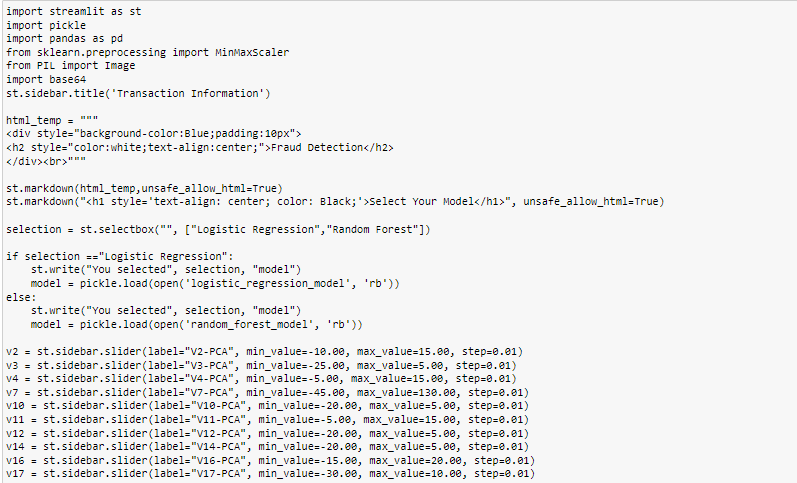

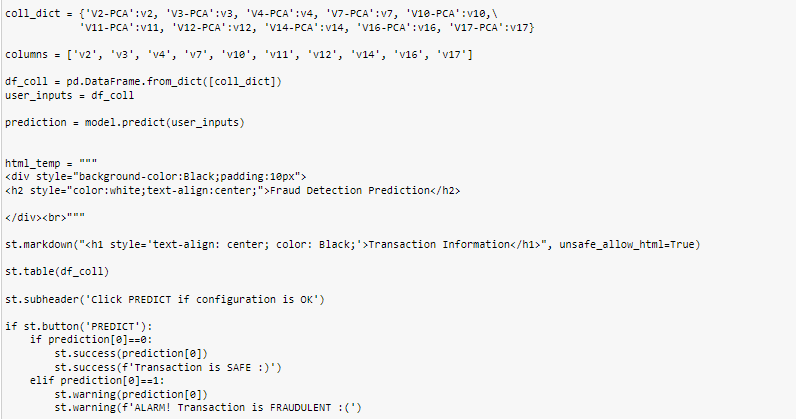

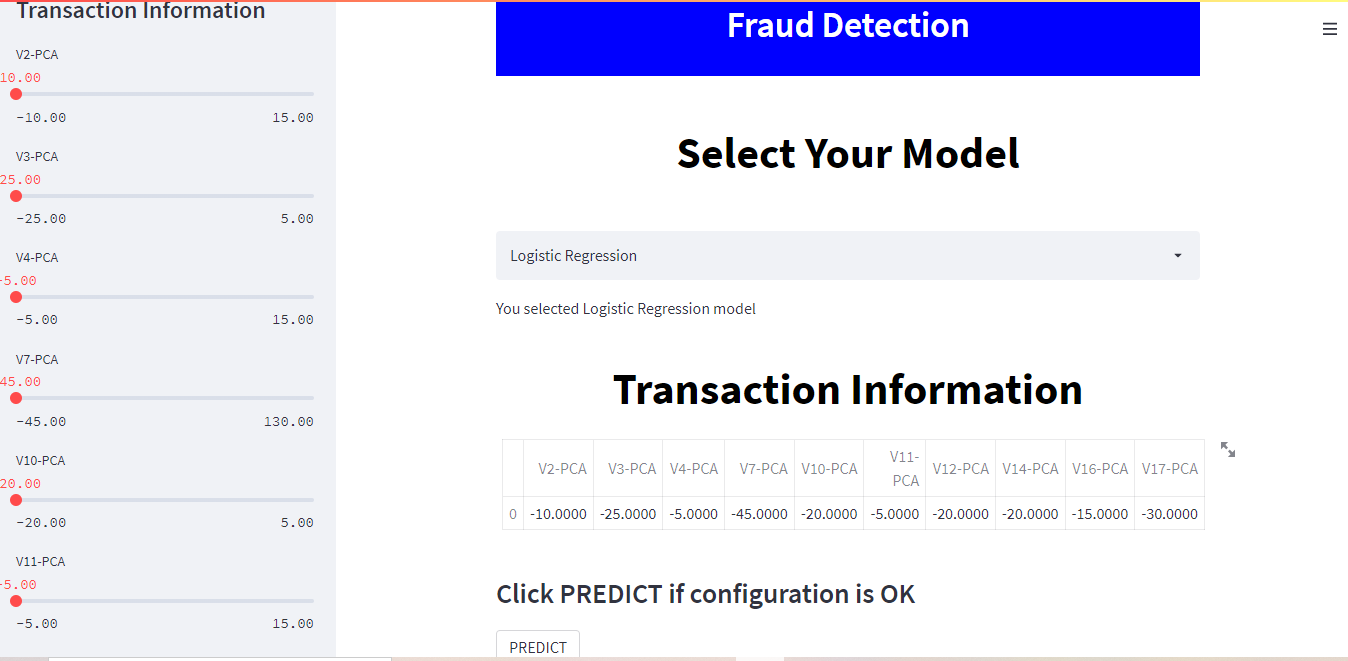

<a id="11"></a>
## <p style="background-color:#B61151; font-family:newtimeroman; color:#FFF9ED; font-size:150%; text-align:center; border-radius:10px 10px;">11 - CONCLUSION<p>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Table of Contents</a>

The datasets contains transactions made by credit cards in September 2013 by european cardholders. A study is requested from us to predict which transaction is fraudulent or not by using this data.

First of all, to observe the structure of the data, outliers, missing values and features that affect the target variable, we used exploratory data analysis and data visualization techniques.

Then, we performed data pre-processing operations to increase the recall score of algorithms.** 

We built models to predict transaction is fraudulent or not. We trained our models with train set, tested the success of models with test set. 

In this study, we made modelling with ***Logistic Regression***, ***Random Forest Classifier*** and ***Neural Network***.

We used scikit-learn ***Confusion Metrics*** module for accuracy calculation and the ***Yellowbrick*** module for model selection and visualization.

Implementing SMOTE Technique on our imbalanced dataset helped us to balanced the data.

After comparison between models, we found that RandomForestClassifier (Befor and After) SMOTE gave us the best result.

I chose the 10 most effective feature according to the correlation, and feature importance results. With these 10 feature and target feature, I create a new dataframe. With this dataframe, I made modelling with Logistic Regression and Random Forest Classifier with SMOTE.

I save  Logistic Regression and Random Forest Classifier as a final model. Then with these final models, I deployed my study via streamlit.

We have come to the end of the study. I hope it was useful. I would be very happy if you send your constructive and educational comments about the kernel.

Please don't forget to upvote if you liked!

You can find an instruction about how to deploy a model at last part of the kernel given below.
https://www.kaggle.com/azizozmen/employee-churn-attrition-predict-eda-multi-algosHow 